# Bài tập: Sử dụng Linear Regression và Polynomial Regression

### Problem:

- Xây dựng một model để dự đoán giá nhà ``MEDV`` dựa trên các thông số khác

-  Dataset: boston_dataset.cs


### Hint:
- Sử dụng cả 2 mô hình: Linear Regression và Polynomial Regression
- Sử dụng Heat Map để xác định xem ``MEDV`` phụ thuộc tuyến tình vào các biến nào; từ đó xây dựng mô hình tuyến tính và mô hình đa thức tương ứng

### Đặc tả dataset:
There are 506 samples and 13 feature variables in this data-set. The objective is to predict the value of prices of the house using the given features.

The description of all the features is given below:

  **CRIM**: Per capita crime rate by town

  **ZN**: Proportion of residential land zoned for lots over 25,000 sq. ft

  **INDUS**: Proportion of non-retail business acres per town

  **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)

  **NOX**: Nitric oxide concentration (parts per 10 million)

  **RM**: Average number of rooms per dwelling

  **AGE**: Proportion of owner-occupied units built prior to 1940

  **DIS**: Weighted distances to five Boston employment centers

  **RAD**: Index of accessibility to radial highways

  **TAX**: Full-value property tax rate per $10,000

  **B**: 1000(Bk - 0.63)², where Bk is the proportion of [people of African American descent] by town

  **LSTAT**: Percentage of lower status of the population

  **MEDV**: Median value of owner-occupied homes in $1000s
  

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
dataset = pd.read_csv("boston_dataset.csv")
dataset

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [6]:
dataset.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

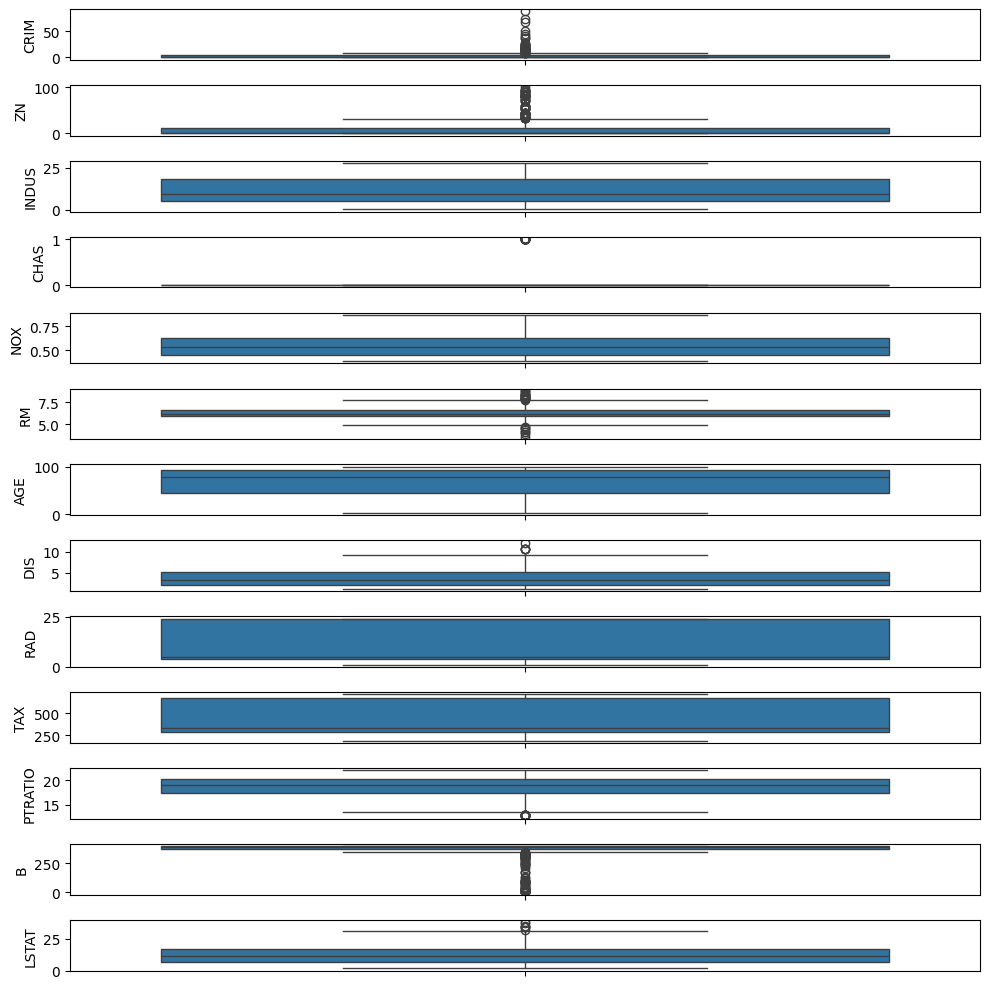

In [10]:
fig, axs = plt.subplots(13, figsize = (10,10))
plt1 = sns.boxplot(dataset['CRIM'], ax = axs[0])
plt2 = sns.boxplot(dataset['ZN'], ax = axs[1])
plt3 = sns.boxplot(dataset['INDUS'], ax = axs[2])
plt4 = sns.boxplot(dataset['CHAS'], ax = axs[3])
plt5 = sns.boxplot(dataset['NOX'], ax = axs[4])
plt6 = sns.boxplot(dataset['RM'], ax = axs[5])
plt7 = sns.boxplot(dataset['AGE'], ax = axs[6])
plt8 = sns.boxplot(dataset['DIS'], ax = axs[7])
plt9 = sns.boxplot(dataset['RAD'], ax = axs[8])
plt10 = sns.boxplot(dataset['TAX'], ax = axs[9])
plt11 = sns.boxplot(dataset['PTRATIO'], ax = axs[10])
plt12 = sns.boxplot(dataset['B'], ax = axs[11])
plt13 = sns.boxplot(dataset['LSTAT'], ax = axs[12])
plt.tight_layout()

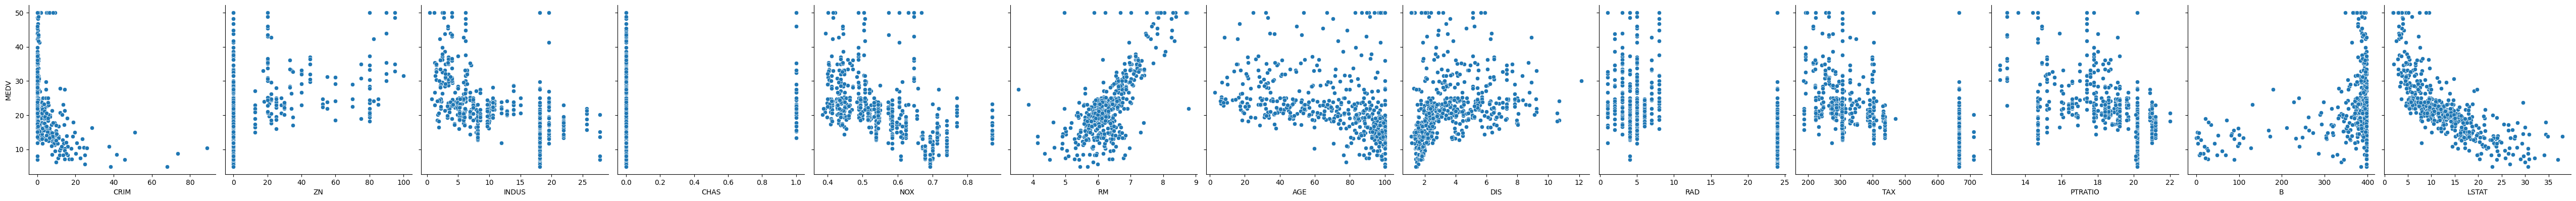

In [14]:
sns.pairplot(dataset, x_vars=['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'], y_vars='MEDV', height=4, aspect=1, kind='scatter')
plt.show()

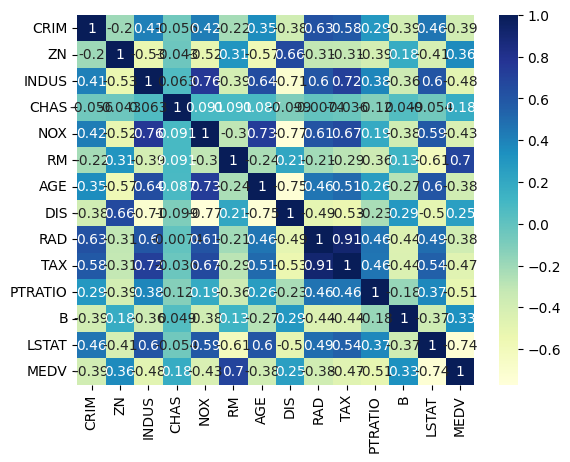

In [15]:
sns.heatmap(dataset.corr(), cmap="YlGnBu", annot = True)
plt.show()

In [23]:
X = pd.DataFrame(dataset['LSTAT'])
Y = pd.DataFrame(dataset['MEDV'])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=100)
model = LinearRegression()
model.fit(X_train, Y_train)
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)
print("Coefficients: ", model.coef_)
print("Intercept: ", model.intercept_)
print("Mean Squared Error: ", mean_squared_error(Y_test, Y_test_pred))

Coefficients:  [[-0.88168388]]
Intercept:  [33.72091623]
Mean Squared Error:  47.37808502510823


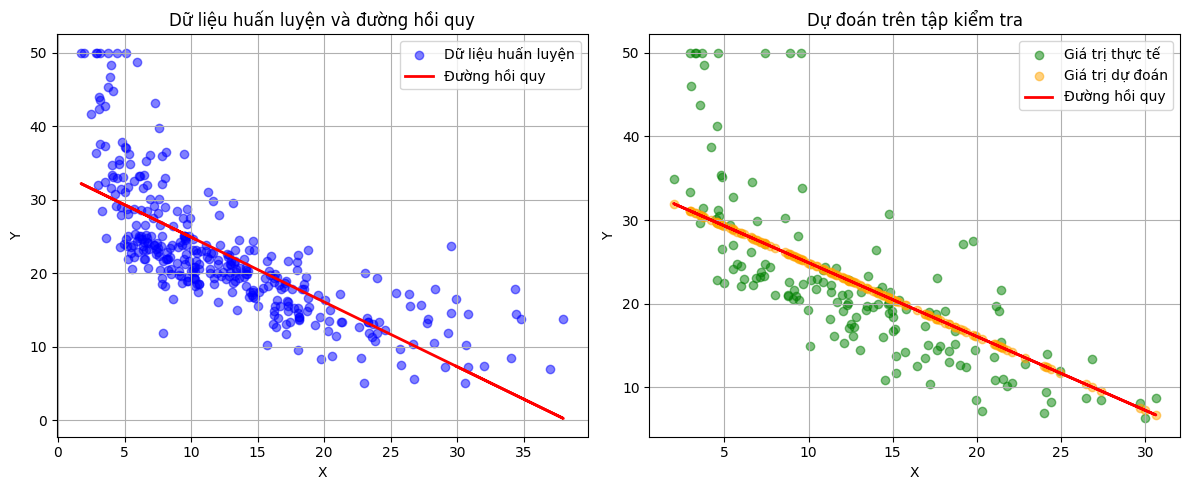

In [24]:
# Vẽ đồ thị kết quả
plt.figure(figsize=(12, 5))

# Subplot 1: Dữ liệu huấn luyện và đường hồi quy
plt.subplot(1, 2, 1)
plt.scatter(X_train, Y_train, color='blue', alpha=0.5, label='Dữ liệu huấn luyện')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Đường hồi quy')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dữ liệu huấn luyện và đường hồi quy')
plt.legend()
plt.grid(True)

# Subplot 2: So sánh giá trị thực tế và dự đoán trên tập test
plt.subplot(1, 2, 2)
plt.scatter(X_test, Y_test, color='green', alpha=0.5, label='Giá trị thực tế')
plt.scatter(X_test, Y_test_pred, color='orange', alpha=0.5, label='Giá trị dự đoán')
plt.plot(X_test, model.predict(X_test), color='red', linewidth=2, label='Đường hồi quy')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dự đoán trên tập kiểm tra')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [31]:
mse_train = mean_squared_error(Y_train, Y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(Y_train, Y_train_pred)
r2_train = r2_score(Y_train, Y_train_pred)

# Metrics trên Test set
mse_test = mean_squared_error(Y_test, Y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(Y_test, Y_test_pred)
r2_test = r2_score(Y_test, Y_test_pred)

# Thông tin dữ liệu
Y_mean = np.mean(Y)
Y_std = np.std(Y)
Y_range = np.max(Y) - np.min(Y)

# ============================================================================
# 2. IN BÁO CÁO CHI TIẾT
# ============================================================================

print("="*80)
print("📊 BÁO CÁO ĐÁNH GIÁ PERFORMANCE - LINEAR REGRESSION")
print("="*80)

print("\n🔹 THÔNG TIN MÔ HÌNH:")
print(f"   Coefficient (Hệ số góc): {model.coef_[0][0]:.6f}")
print(f"   Intercept (Hệ số chặn):  {model.intercept_[0]:.6f}")
print(f"   Phương trình: Y = {model.intercept_[0]:.2f} + ({model.coef_[0][0]:.2f}) * X")

if model.coef_[0][0] > 0:
    print(f"   → Mối quan hệ: THUẬN (X tăng → Y tăng)")
else:
    print(f"   → Mối quan hệ: NGHỊCH (X tăng → Y giảm)")


print("\n🔹 METRICS TRÊN TẬP TRAIN:")
print(f"   MSE  (Mean Squared Error):      {mse_train:.6f}")
print(f"   RMSE (Root Mean Squared Error): {rmse_train:.6f}")
print(f"   MAE  (Mean Absolute Error):     {mae_train:.6f}")
print(f"   R²   (R-squared):               {r2_train:.6f} ({r2_train*100:.2f}%)")

print("\n🔹 METRICS TRÊN TẬP TEST:")
print(f"   MSE  (Mean Squared Error):      {mse_test:.6f}")
print(f"   RMSE (Root Mean Squared Error): {rmse_test:.6f}")
print(f"   MAE  (Mean Absolute Error):     {mae_test:.6f}")
print(f"   R²   (R-squared):               {r2_test:.6f} ({r2_test*100:.2f}%)")

print("\n🔹 SO SÁNH TRAIN vs TEST:")
r2_diff = abs(r2_train - r2_test)
rmse_diff = abs(rmse_train - rmse_test)
print(f"   Chênh lệch R²:   {r2_diff:.6f}")
print(f"   Chênh lệch RMSE: {rmse_diff:.6f}")

print("\n🔹 ĐÁNH GIÁ RMSE:")
rmse_percentage = (rmse_test / Y_mean) * 100
print(f"   RMSE / Mean Y: {rmse_percentage:.2f}%")
if rmse_percentage < 10:
    print(f"   → RẤT TỐT (RMSE < 10% mean)")
elif rmse_percentage < 20:
    print(f"   → TỐT (RMSE < 20% mean)")
elif rmse_percentage < 30:
    print(f"   → CHẤP NHẬN ĐƯỢC (RMSE < 30% mean)")
else:
    print(f"   → CẦN CẢI THIỆN (RMSE > 30% mean)")

print("\n🔹 ĐÁNH GIÁ R² SCORE:")
if r2_test > 0.9:
    print(f"   → RẤT TỐT (R² > 0.9)")
elif r2_test > 0.7:
    print(f"   → TỐT (R² > 0.7)")
elif r2_test > 0.5:
    print(f"   → TRUNG BÌNH (R² > 0.5)")
elif r2_test > 0.3:
    print(f"   → YẾU (R² > 0.3)")
else:
    print(f"   → RẤT YẾU (R² < 0.3)")

print("\n🔹 ĐÁNH GIÁ OVERFITTING:")
if r2_diff < 0.05:
    print(f"   → KHÔNG bị Overfitting (|ΔR²| < 0.05) ✅")
elif r2_diff < 0.1:
    print(f"   → CÓ DẤU HIỆU Overfitting nhẹ (|ΔR²| < 0.1) ⚠️")
else:
    print(f"   → BỊ OVERFITTING (|ΔR²| >= 0.1) ❌")

print("\n✅ KẾT LUẬN TỔNG THỂ:")
if r2_test > 0.7 and r2_diff < 0.05 and rmse_percentage < 20:
    print("   🎉 Mô hình XUẤT SẮC!")
elif r2_test > 0.5 and r2_diff < 0.1:
    print("   👍 Mô hình TỐT, có thể sử dụng!")
elif r2_test > 0.3:
    print("   ⚠️ Mô hình TRUNG BÌNH, cần cải thiện!")
else:
    print("   ❌ Mô hình YẾU, cần xem xét lại!")

print("="*80)

📊 BÁO CÁO ĐÁNH GIÁ PERFORMANCE - LINEAR REGRESSION

🔹 THÔNG TIN MÔ HÌNH:
   Coefficient (Hệ số góc): -0.881684
   Intercept (Hệ số chặn):  33.720916
   Phương trình: Y = 33.72 + (-0.88) * X
   → Mối quan hệ: NGHỊCH (X tăng → Y giảm)

🔹 METRICS TRÊN TẬP TRAIN:
   MSE  (Mean Squared Error):      35.005075
   RMSE (Root Mean Squared Error): 5.916509
   MAE  (Mean Absolute Error):     4.358720
   R²   (R-squared):               0.546342 (54.63%)

🔹 METRICS TRÊN TẬP TEST:
   MSE  (Mean Squared Error):      47.378085
   RMSE (Root Mean Squared Error): 6.883174
   MAE  (Mean Absolute Error):     4.810728
   R²   (R-squared):               0.532230 (53.22%)

🔹 SO SÁNH TRAIN vs TEST:
   Chênh lệch R²:   0.014112
   Chênh lệch RMSE: 0.966665

🔹 ĐÁNH GIÁ RMSE:
   RMSE / Mean Y: 30.55%
   → CẦN CẢI THIỆN (RMSE > 30% mean)

🔹 ĐÁNH GIÁ R² SCORE:
   → TRUNG BÌNH (R² > 0.5)

🔹 ĐÁNH GIÁ OVERFITTING:
   → KHÔNG bị Overfitting (|ΔR²| < 0.05) ✅

✅ KẾT LUẬN TỔNG THỂ:
   👍 Mô hình TỐT, có thể sử dụng!
